# fio DFS Heatmap Sweep — numjobs × block size

Analyzes results from a sweep of `(numjobs, block_size)` pairs with the DAOS DFS ioengine.  
Fixed `iodepth=16` throughout. Produces heatmaps of **throughput (BW, IOPS)** and **latency**.

- **Axes:** block size ∈ {4k, 16k, 1m, 2m, 4m} × numjobs ∈ {4, 8, 16, 32, 64}
- **Patterns:** `rand_write`, `seq_read`

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
NJ_ORDER = [4, 8, 16, 32, 64]

In [2]:
def bs_to_bytes(bs: str) -> int:
    bs = bs.lower()
    if bs.endswith("k"):
        return int(bs[:-1]) * 1024
    if bs.endswith("m"):
        return int(bs[:-1]) * 1024 ** 2
    return int(bs)


def parse_file(fpath: Path) -> dict:
    m = re.search(r"fio_\w+_bs(\w+?)_nj(\d+)_iod(\d+)_", fpath.name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job = d["jobs"][0]
    io = job["read"] if job["read"]["io_bytes"] > 0 else job["write"]
    clat = io["clat_ns"]
    lat  = io["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        bs             = bs,
        numjobs        = nj,
        iodepth        = iod,
        bw_GiBs        = io["bw_bytes"] / 1024 ** 3,
        iops           = io["iops"],
        lat_min_ms     = ms(lat["min"]),
        lat_mean_ms    = ms(lat["mean"]),
        lat_max_ms     = ms(lat["max"]),
        clat_mean_ms   = ms(clat["mean"]),
        clat_p50_ms    = ms(cp["50.000000"]),
        clat_p90_ms    = ms(cp["90.000000"]),
        clat_p99_ms    = ms(cp["99.000000"]),
        clat_p99_9_ms  = ms(cp["99.900000"]),
        clat_p99_99_ms = ms(cp["99.990000"]),
    )


def make_annot(p, fmt, ann_fn=None):
    if ann_fn is None:
        return True, fmt
    annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")
    return annot, ""

## rand_write — Load Results

In [3]:
rw_files = sorted(RESULTS_DIR.glob("fio_rand_write_*.json"))
df_rw = pd.DataFrame([parse_file(f) for f in rw_files])

df_rw["bs_bytes"] = df_rw["bs"].apply(bs_to_bytes)
df_rw["bs"]       = pd.Categorical(df_rw["bs"],       categories=BS_ORDER, ordered=True)
df_rw["numjobs"]  = pd.Categorical(df_rw["numjobs"],  categories=NJ_ORDER, ordered=True)
df_rw = df_rw.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

print(f"Loaded {len(df_rw)} rand_write result files  (iodepth={df_rw['iodepth'].unique()})")
df_rw

Loaded 25 rand_write result files  (iodepth=[16])


,bs,numjobs,iodepth,bw_GiBs,iops,lat_min_ms,lat_mean_ms,lat_max_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,2.543760,6.668313e+05,0.028630,0.095653,29.578281,0.092305,0.083456,0.107008,0.128512,1.662976,3.588096,4096
1,4k,8,16,4.816213,1.262541e+06,0.028190,0.101037,33.060090,0.097643,0.084480,0.110080,0.288768,2.244608,6.193152,4096
2,4k,16,16,7.068606,1.852993e+06,0.028010,0.137772,53.569250,0.134130,0.067072,0.284672,1.105920,4.227072,9.764864,4096
3,4k,32,16,5.937665,1.556523e+06,0.027781,0.328381,105.269842,0.324485,0.268288,0.497664,1.925120,7.962624,17.694720,4096
4,4k,64,16,5.770508,1.512704e+06,0.028001,0.675350,365.101280,0.671038,0.391168,1.286144,4.816896,13.697024,35.913728,4096
5,16k,4,16,7.789523,5.104942e+05,0.033481,0.125027,39.784395,0.120520,0.101888,0.129536,0.214016,3.817472,13.303808,16384
6,16k,8,16,13.851657,9.077822e+05,0.033501,0.140659,39.227853,0.136083,0.098816,0.129536,1.105920,7.110656,14.876672,16384
7,16k,16,16,15.664027,1.026558e+06,0.033740,0.248942,50.287224,0.244264,0.121344,0.246784,3.293184,10.682368,20.578304,16384
8,16k,32,16,16.178149,1.060251e+06,0.035211,0.482158,116.784831,0.476959,0.317440,0.514048,6.258688,14.090240,30.277632,16384
9,16k,64,16,16.777415,1.099525e+06,0.035431,0.929178,332.349517,0.923394,0.692224,1.056768,8.716288,22.151168,57.933824,16384


## rand_write — Bandwidth / IOPS / Mean Latency Heatmaps

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_17235/3156116160.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")


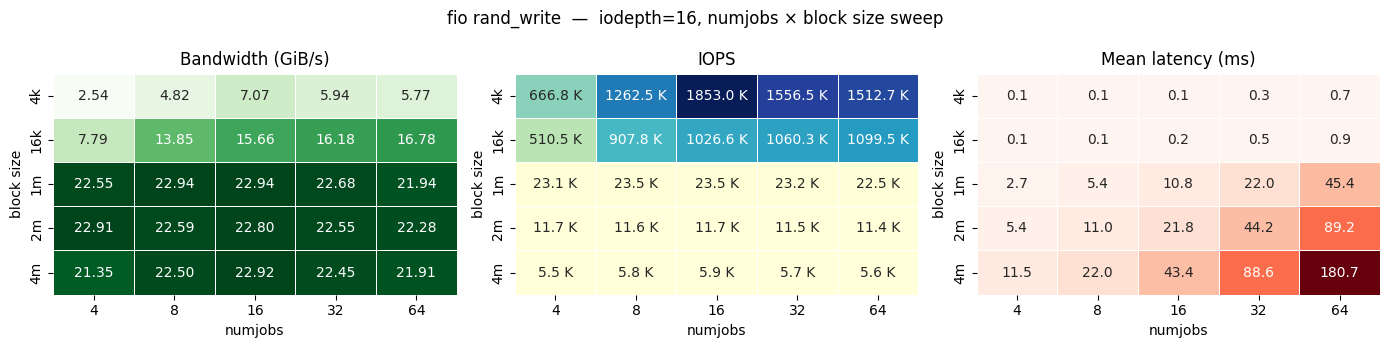

In [4]:
def pivot_rw(metric):
    return df_rw.pivot(index="bs", columns="numjobs", values=metric).reindex(
        index=BS_ORDER, columns=NJ_ORDER
    )


rw_specs = [
    ("bw_GiBs",      "Bandwidth (GiB/s)", ".2f", "Greens", None),
    ("iops",         "IOPS",              ".0f", "YlGnBu", lambda v: f"{v/1e3:.1f} K"),
    ("clat_mean_ms", "Mean latency (ms)", ".1f", "Reds",   None),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (metric, label, fmt, cmap, ann_fn) in zip(axes, rw_specs):
    p = pivot_rw(metric)
    annot, efmt = make_annot(p, fmt, ann_fn)
    sns.heatmap(
        p, ax=ax, cmap=cmap, annot=annot, fmt=efmt,
        linewidths=0.5, cbar=False,
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio rand_write  —  iodepth=16, numjobs × block size sweep")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_nj-bs.pdf", bbox_inches="tight", dpi=150)
plt.show()

## rand_write — Latency Percentile Heatmaps

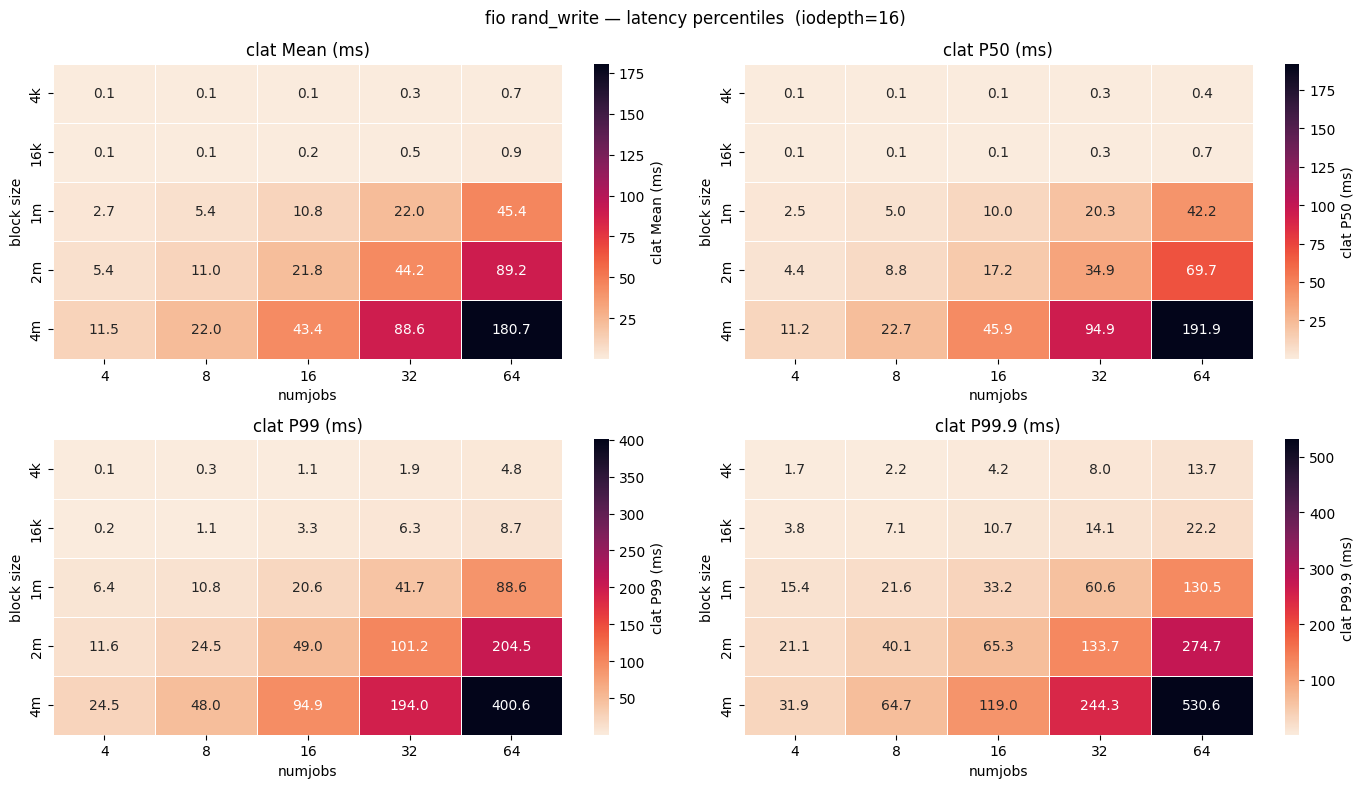

In [5]:
lat_metrics = [
    ("clat_mean_ms",   "clat Mean (ms)"),
    ("clat_p50_ms",    "clat P50 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, lat_metrics):
    p = pivot_rw(metric)
    sns.heatmap(
        p, ax=ax, cmap="rocket_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio rand_write — latency percentiles  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## rand_write — Tail Latency Detail

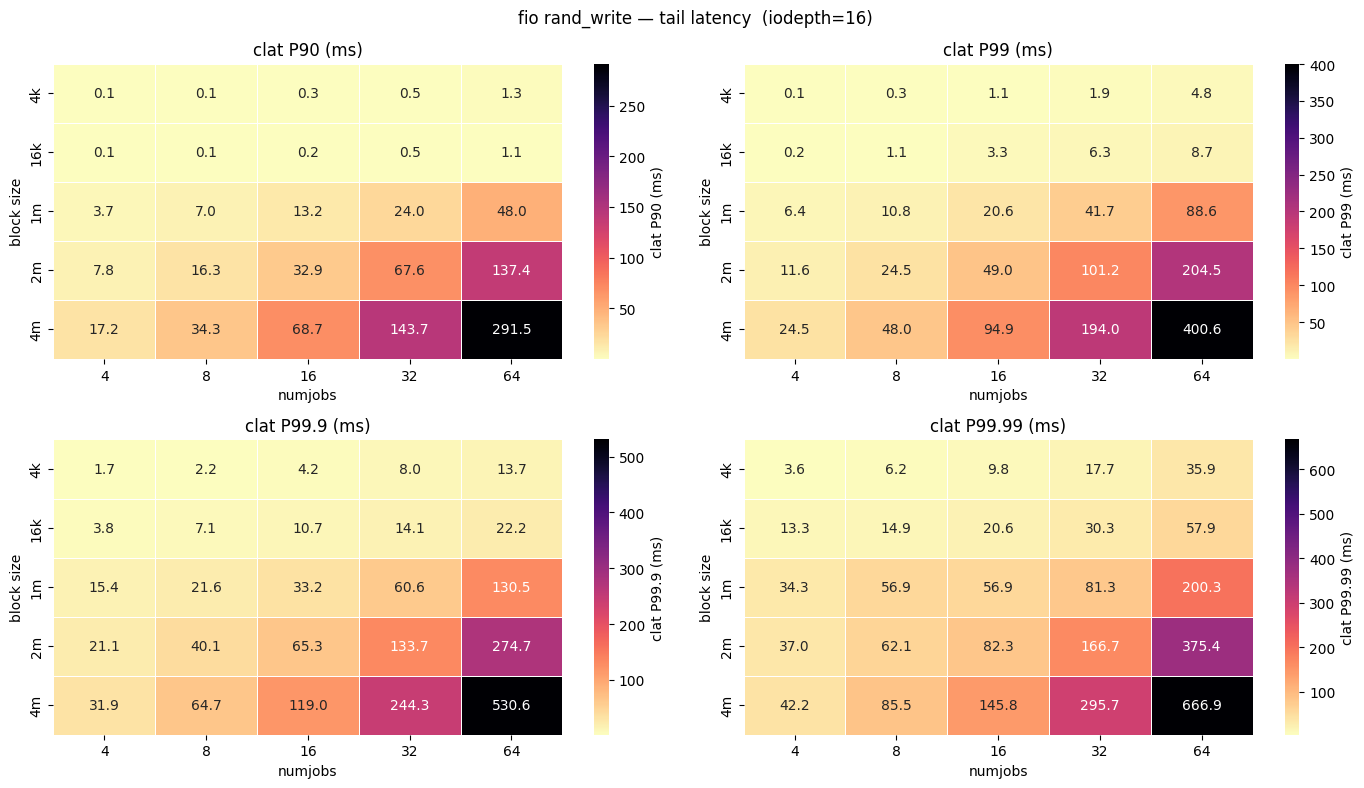

In [6]:
tail_metrics = [
    ("clat_p90_ms",    "clat P90 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
    ("clat_p99_99_ms", "clat P99.99 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, tail_metrics):
    p = pivot_rw(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio rand_write — tail latency  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_tail_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## seq_read — Load Results

In [7]:
sr_files = [f for f in sorted(RESULTS_DIR.glob("fio_seq_read_*.json")) if f.stat().st_size > 0]
df_sr = pd.DataFrame([parse_file(f) for f in sr_files])

df_sr["bs_bytes"] = df_sr["bs"].apply(bs_to_bytes)
df_sr["bs"]       = pd.Categorical(df_sr["bs"],       categories=BS_ORDER, ordered=True)
df_sr["numjobs"]  = pd.Categorical(df_sr["numjobs"],  categories=NJ_ORDER, ordered=True)
df_sr = df_sr.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

print(f"Loaded {len(df_sr)} seq_read result files  (iodepth={df_sr['iodepth'].unique()})")
df_sr

Loaded 22 seq_read result files  (iodepth=[16])


,bs,numjobs,iodepth,bw_GiBs,iops,lat_min_ms,lat_mean_ms,lat_max_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,0.706231,185134.181097,0.078192,0.345364,14.004080,0.341208,0.354304,0.493568,0.593920,1.044480,10.158080,4096
1,4k,8,16,1.405917,368552.790787,0.077961,0.346976,15.242644,0.343027,0.358400,0.497664,0.602112,1.044480,10.158080,4096
2,4k,16,16,2.701841,708271.472853,0.079741,0.361074,17.776265,0.357034,0.366592,0.514048,0.708608,1.449984,10.813440,4096
3,4k,32,16,2.758596,723149.335066,0.084871,0.707510,39.004008,0.703215,0.634880,1.089536,1.531904,4.554752,12.386304,4096
4,4k,64,16,3.018795,791359.076062,0.081012,1.293099,56.568120,1.288743,1.269760,1.613824,2.703360,9.633792,16.580608,4096
5,16k,4,16,2.120794,138988.333722,0.112492,0.460062,16.691104,0.454933,0.415744,0.684032,0.995328,1.433600,12.648448,16384
6,16k,8,16,2.397855,157145.795140,0.114823,0.814108,19.812246,0.808925,0.765952,1.138688,1.564672,6.586368,14.876672,16384
7,16k,16,16,2.964118,194256.458118,0.121423,1.317192,21.577511,1.311867,1.335296,1.777664,2.244608,9.502720,15.663104,16384
8,16k,32,16,3.616150,236988.033932,0.140903,2.159432,41.279124,2.153939,2.277376,2.965504,3.522560,11.468800,18.743296,16384
9,16k,64,16,3.616003,236978.385135,0.150303,4.318880,54.020748,4.313039,4.882432,5.865472,6.848512,20.054016,38.010880,16384


## seq_read — Bandwidth / IOPS / Mean Latency Heatmaps

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_17235/3156116160.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")


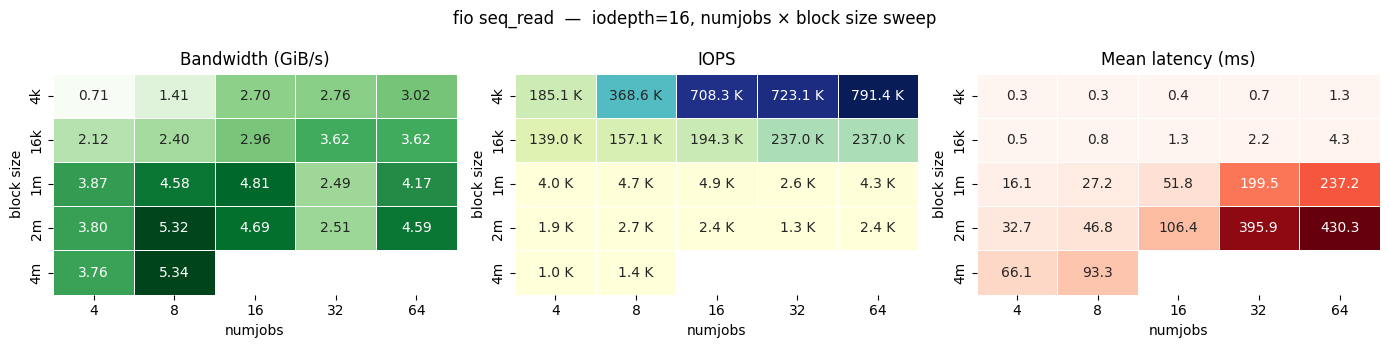

In [8]:
def pivot_sr(metric):
    return df_sr.pivot(index="bs", columns="numjobs", values=metric).reindex(
        index=BS_ORDER, columns=NJ_ORDER
    )


sr_specs = [
    ("bw_GiBs",      "Bandwidth (GiB/s)", ".2f", "Greens", None),
    ("iops",         "IOPS",              ".0f", "YlGnBu", lambda v: f"{v/1e3:.1f} K"),
    ("clat_mean_ms", "Mean latency (ms)", ".1f", "Reds",   None),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (metric, label, fmt, cmap, ann_fn) in zip(axes, sr_specs):
    p = pivot_sr(metric)
    annot, efmt = make_annot(p, fmt, ann_fn)
    sns.heatmap(
        p, ax=ax, cmap=cmap, annot=annot, fmt=efmt,
        linewidths=0.5, cbar=False,
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio seq_read  —  iodepth=16, numjobs × block size sweep")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_nj-bs.pdf", bbox_inches="tight", dpi=150)
plt.show()

## seq_read — Latency Percentile Heatmaps

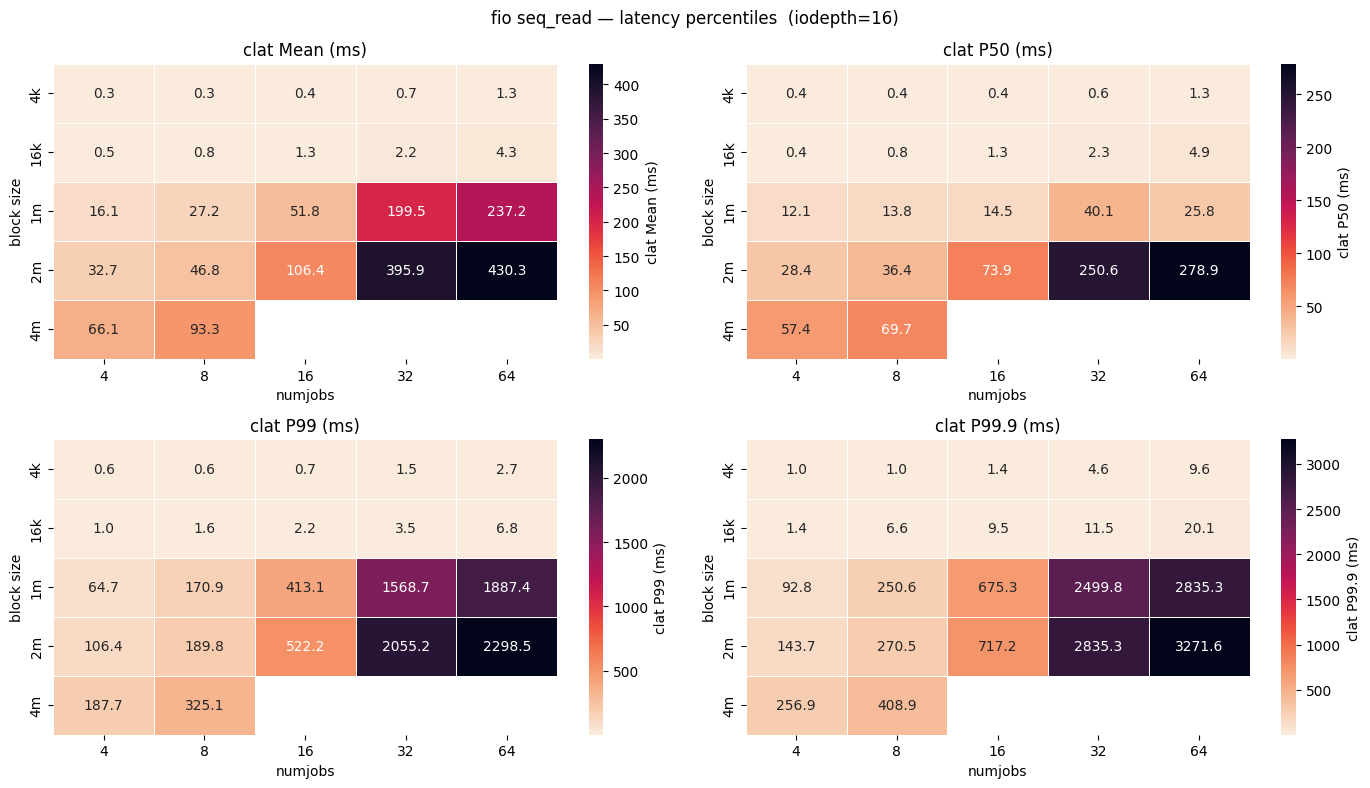

In [9]:
lat_metrics_sr = [
    ("clat_mean_ms",   "clat Mean (ms)"),
    ("clat_p50_ms",    "clat P50 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, lat_metrics_sr):
    p = pivot_sr(metric)
    sns.heatmap(
        p, ax=ax, cmap="rocket_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio seq_read — latency percentiles  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## seq_read — Tail Latency Detail

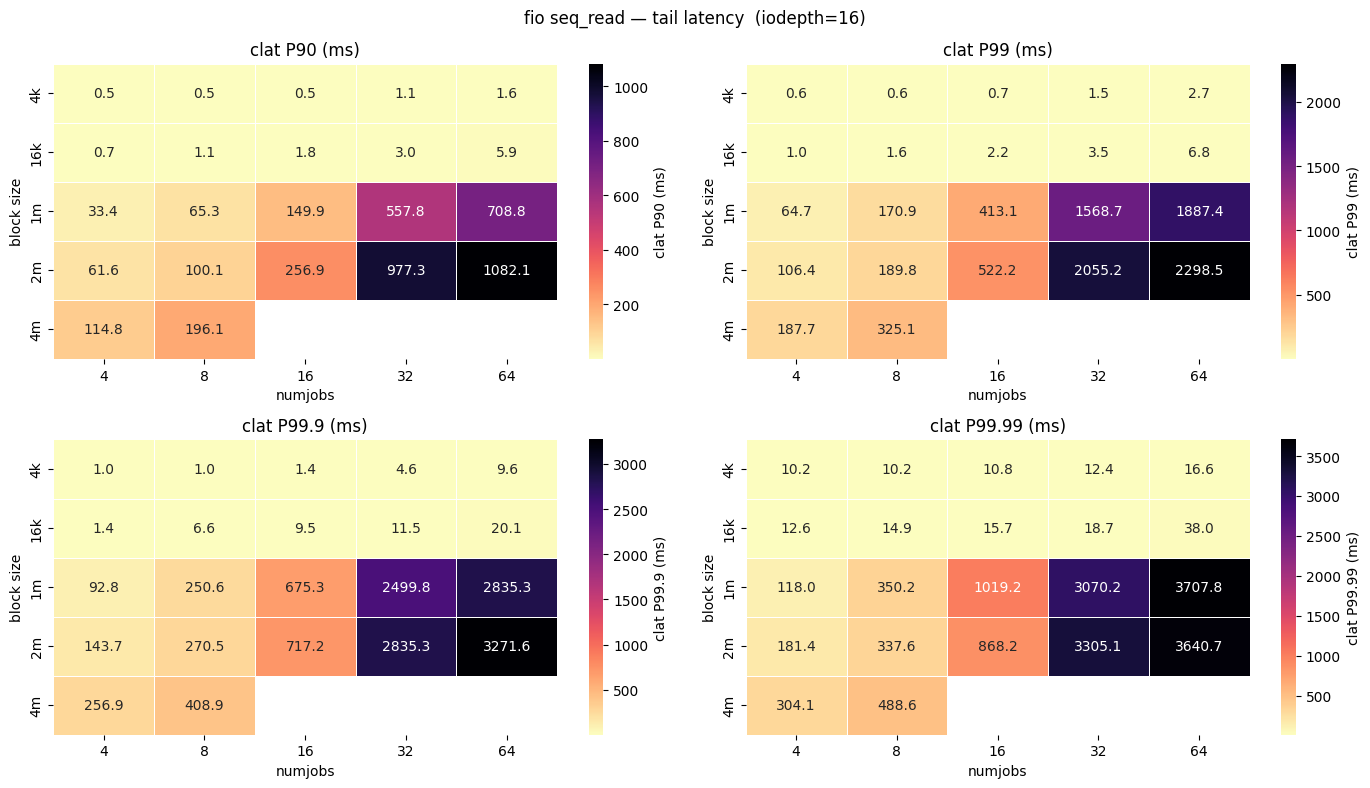

In [10]:
tail_metrics_sr = [
    ("clat_p90_ms",    "clat P90 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
    ("clat_p99_99_ms", "clat P99.99 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, tail_metrics_sr):
    p = pivot_sr(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_title(label)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("fio seq_read — tail latency  (iodepth=16)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_tail_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()